## 1. Importing Libraries Learning to make proper jupyter notebooks

In [1]:
import numpy as np
import pandas as pd
from ISLP import load_data
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
import statsmodels.api as sm
import sklearn
from sklearn.model_selection import train_test_split
from scipy import stats
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

In [2]:
import warnings

warnings.filterwarnings("ignore")

### Loading and understanding data

In [3]:
df = pd.read_csv("advertising.csv")

### Dataset says the company spend advertising money by three modes, TV, newspaper and radio and generated this much sales
**Goal is to build a regression model using these 3 variables, sales is the target variable**

In [4]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [6]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [7]:
df["TV"].median()

np.float64(149.75)

## 2. Quick overall visualization of the data

<Figure size 900x700 with 0 Axes>

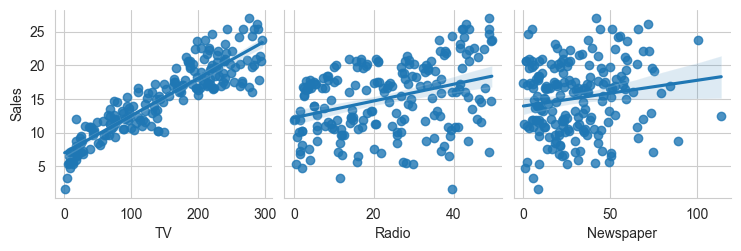

In [8]:
plt.figure(figsize=(9, 7))
sns.pairplot(df, x_vars=["TV", "Radio", "Newspaper"], y_vars="Sales", kind="reg")
plt.show()

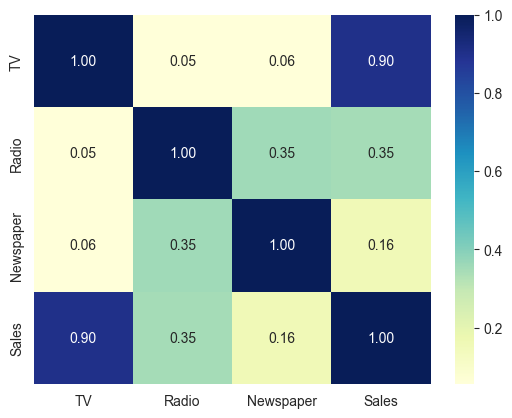

In [9]:
sns.heatmap(df.corr(), cmap="YlGnBu", annot=True, fmt=".2f")
plt.show()

### Linear Regression equation: Y = Βo + Β1x
Βo is the intercept and Β1 is the slope of the equation
building a linear regression model using gradient descent

### EDA

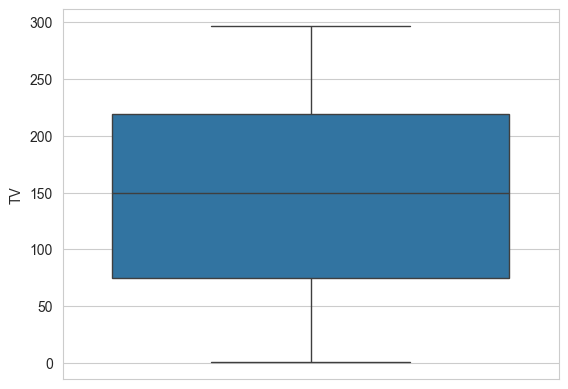

In [10]:
sns.boxplot(
    df,
    y="TV",
)
plt.show()

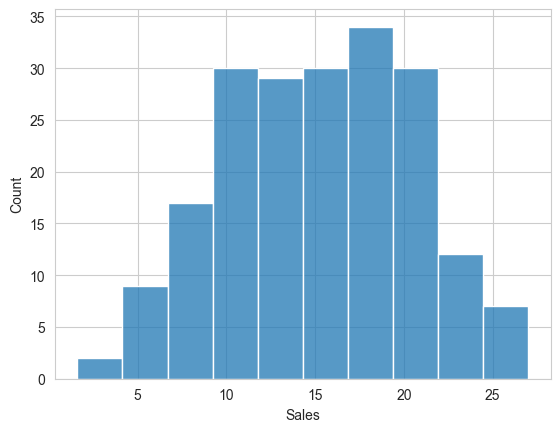

In [11]:
sns.histplot(df, x="Sales")
plt.show()

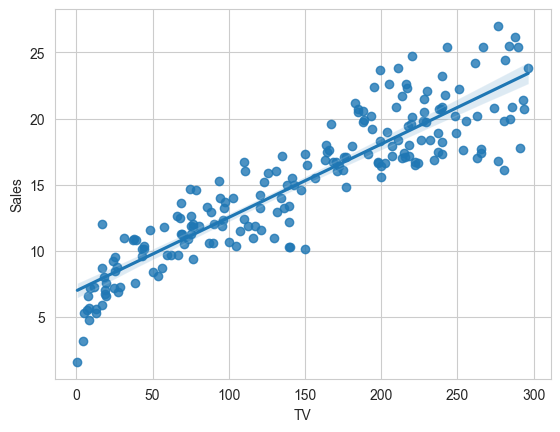

In [12]:
sns.regplot(data=df, x="TV", y="Sales")
plt.show()

---
## 3: Performing Simple Linear Regression

Equation of linear regression<br>
$y = c + m_1x_1 + m_2x_2 + ... + m_nx_n$

-  $y$ is the response
-  $c$ is the intercept
-  $m_1$ is the coefficient for the first feature
-  $m_n$ is the coefficient for the nth feature<br>

In our case:

$y = c + m_1 \times TV$

The $m$ values are called the model **coefficients** or **model parameters**.

---

In [13]:
0.5 / (0.2 / 5) * 2

25.0

In [14]:
stats.norm.ppf(1 - 0.05 / 2)

np.float64(1.959963984540054)

### 3.1 Next step in linear regression is hypothesis testing
The claim is there is no relationship between X and Y that we say in line Y = B0 + B1x B1=0, that is our Ho to say there is a relationship we formulate an alternate hypothesis H1 by first computing the t-score
X-mu/s/sqrt(n), that is our alternate hypothesis is (B1_hat - 0)/SE(B1_hat) SE is standard Error

In [15]:
stats.ttest_1samp(df["TV"], df["Sales"].mean())

TtestResult(statistic=np.float64(21.72889160128329), pvalue=np.float64(1.9728914209241963e-54), df=np.int64(199))

### 3.2 Steps
- Create X and y
- Create train and test set (70-30) or (80-20)
- Create your model using the train set (learn coefficients
- Evaluate the model (training set, test set)

In [16]:
# creating X and y
X = df["TV"]
y = df["Sales"]

### 3.2.2 Train test split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=100
)

In [18]:
X_train

74     213.4
3      151.5
185    205.0
26     142.9
90     134.3
       ...  
87     110.7
103    187.9
67     139.3
24      62.3
8        8.6
Name: TV, Length: 140, dtype: float64

### 3.2.2.2 First using stats models

In [19]:
# training model using statsmodels, adding constant
X_train_stats = sm.add_constant(X_train)

In [20]:
X_train_stats

,const,TV
74,1.0,213.4
3,1.0,151.5
185,1.0,205.0
26,1.0,142.9
90,1.0,134.3
...,...,...
87,1.0,110.7
103,1.0,187.9
67,1.0,139.3
24,1.0,62.3


In [21]:
# const 1 because otherwise statsmodels makes it 0

In [22]:
# fitting the model
linear_req = sm.OLS(y_train, X_train_stats)
linear_req_model = linear_req.fit()
dir(linear_req_model)

['HC0_se',
 'HC1_se',
 'HC2_se',
 'HC3_se',
 '_HCCM',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abat_diagonal',
 '_cache',
 '_data_attr',
 '_data_in_cache',
 '_get_robustcov_results',
 '_get_wald_nonlinear',
 '_is_nested',
 '_transform_predict_exog',
 '_use_t',
 '_wexog_singular_values',
 'aic',
 'bic',
 'bse',
 'centered_tss',
 'compare_f_test',
 'compare_lm_test',
 'compare_lr_test',
 'condition_number',
 'conf_int',
 'conf_int_el',
 'cov_HC0',
 'cov_HC1',
 'cov_HC2',
 'cov_HC3',
 'cov_kwds',
 'cov_params',
 'cov_type',
 'df_model',
 'df_resid',
 'eigenvals',
 'el_test',
 'ess',
 'f_pvalue',
 'f_test',
 'fittedvalues',
 'fvalue',
 'get_influe

In [23]:
linear_req_model.params

const    6.948683
TV       0.054546
dtype: float64

In [24]:
# linear_req_model.params[0]

In [25]:
linear_req_model.outlier_test()

,student_resid,unadj_p,bonf(p)
74,-0.659874,0.510443,1.0
3,0.533549,0.594518,1.0
185,1.876247,0.062749,1.0
26,0.106273,0.915521,1.0
90,-0.113505,0.909797,1.0
...,...,...,...
87,1.255090,0.211583,1.0
103,1.040517,0.299932,1.0
67,-0.475146,0.635440,1.0
24,-0.268661,0.788595,1.0


### Statistical Summary of the model

In [26]:
linear_req_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.816
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     611.2
Date:                Sat, 10 May 2025   Prob (F-statistic):           1.52e-52
Time:                        15:23:08   Log-Likelihood:                -321.12
No. Observations:                 140   AIC:                             646.2
Df Residuals:                     138   BIC:                             652.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          6.9487      0.385     18.068      0.000       6.188       7.709
TV             0.0545      0.002     24.722      0.000       0.050       0.059
==============================================================================
Omnibus:                        0.027   Durbin-Watson:                   2.196
Prob(Omnibus):                  0.987   Jarque-Bera (JB):                0.150
Skew:                          -0.006   Prob(JB):                        0.928
Kurtosis:                       2.840   Cond. No.                         328.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [27]:
stats.norm.ppf(linear_req_model.params[1])

np.float64(-1.6022899553885592)

In [28]:
linear_req_model.tvalues

const    18.068249
TV       24.721620
dtype: float64

In [29]:
with open("summary.txt", "w") as f:
    f.write(str(linear_req_model.summary()))

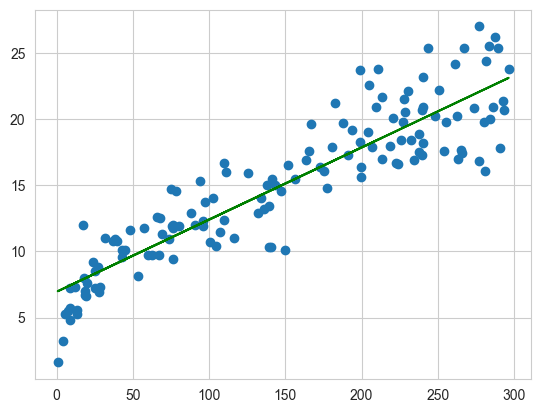

In [30]:
## Visualising accuracy
plt.scatter(X_train, y_train)
plt.plot(
    X_train, linear_req_model.params[0] + linear_req_model.params[1] * X_train, "green"
)
plt.show()

## 4. Residual Analysis.. specific to linear regression

In [31]:
# Calculating errors f(y_train,y_train_pred)

In [32]:
y_train_pred = linear_req_model.predict(X_train_stats)

In [33]:
eq = linear_req_model.params[0] + linear_req_model.params[1] * X_train

In [34]:
(np.array(y_train_pred) == np.array(eq))

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [35]:
a1 = np.array(eq)
a2 = np.array(y_train_pred)
np.setdiff1d(a1, a2)

array([], dtype=float64)

In [36]:
residuals = y_train - y_train_pred

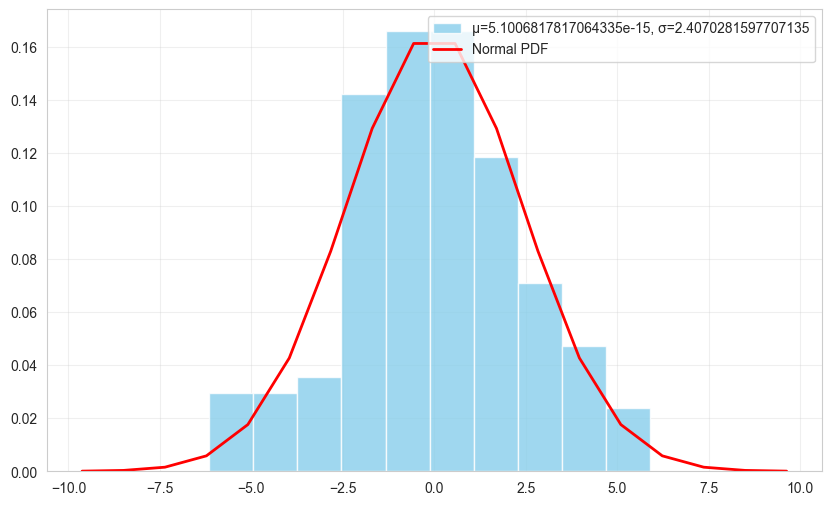

In [37]:
mean = residuals.mean()
std = residuals.std()
x = np.linspace(mean - 4 * std, mean + 4 * std, 18)  # N=10
plt.figure(figsize=(10, 6))
plt.hist(
    residuals,
    bins=10,
    density=True,
    alpha=0.8,
    color="skyblue",
    label=f"μ={mean}, σ={std}",
)
plt.plot(
    x,
    1 / (std * np.sqrt(2 * np.pi)) * np.exp(-((x - mean) ** 2) / (2 * std**2)),
    "r-",
    lw=2,
    label="Normal PDF",
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Predictions on test set

In [38]:
# Predictions on test set
X_test_stats = sm.add_constant(X_test)
y_test_pred = linear_req_model.predict(X_test_stats)

In [39]:
y_test_pred.head()

126     7.374140
104    19.941482
99     14.323269
92     18.823294
111    20.132392
dtype: float64

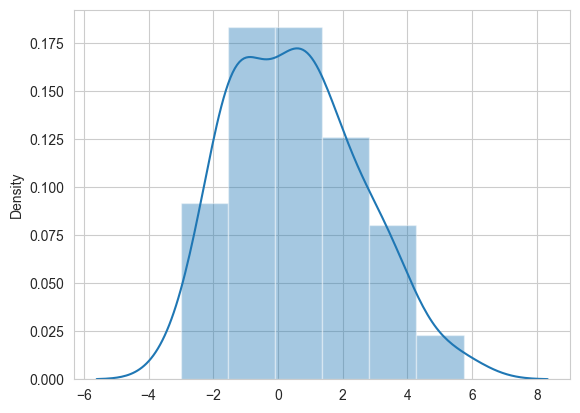

In [40]:
sns.distplot(y_test - y_test_pred)
plt.show()

In [41]:
residuals_test = y_test - y_test_pred

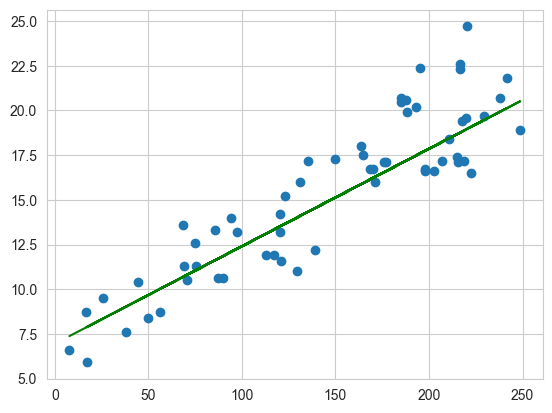

In [42]:
## Visualising accuracy
plt.scatter(X_test, y_test)
plt.plot(X_test, y_test_pred, "green")
plt.show()

In [43]:
r2_score(y_test, y_test_pred)

0.7921031601245656

In [44]:
mean_squared_error(y_test, y_test_pred)

4.077556371826959

## 6. Linear Regression using scikit-learn  (sklearn library)

In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=100
)

In [46]:
# Reshaping
X_train_lm = X_train.values.reshape(-1, 1)
# y_train_lm = y_train.values.reshape(-1,1)
X_test_lm = X_test.values.reshape(-1, 1)
# y_test_lm = y_test.values.reshape(-1,1)

In [47]:
# Steps:

# 1. Create an object of Linear Regression
lin = LinearRegression()
# 2. Fit the model
lin.fit(X_train_lm, y_train)

LinearRegression()

In [48]:
# 3. See the parameters
help(lin)

Help on LinearRegression in module sklearn.linear_model._base object:

class LinearRegression(sklearn.base.MultiOutputMixin, sklearn.base.RegressorMixin, LinearModel)
 |  LinearRegression(*, fit_intercept=True, copy_X=True, n_jobs=None, positive=False)
 |
 |  Ordinary least squares Linear Regression.
 |
 |  LinearRegression fits a linear model with coefficients w = (w1, ..., wp)
 |  to minimize the residual sum of squares between the observed targets in
 |  the dataset, and the targets predicted by the linear approximation.
 |
 |  Parameters
 |  ----------
 |  fit_intercept : bool, default=True
 |      Whether to calculate the intercept for this model. If set
 |      to False, no intercept will be used in calculations
 |      (i.e. data is expected to be centered).
 |
 |  copy_X : bool, default=True
 |      If True, X will be copied; else, it may be overwritten.
 |
 |  n_jobs : int, default=None
 |      The number of jobs to use for the computation. This will only provide
 |      speed

In [49]:
print(lin.intercept_, lin.coef_)

6.948683200001357 [0.05454575]


In [50]:
# make predictions
y_train_pred = lin.predict(X_train_lm)
y_test_pred = lin.predict(X_test_lm)

In [51]:
# Residuals and mse
r2 = r2_score(y_test, y_test_pred)
r2

0.7921031601245662

In [52]:
print(r2_score(y_train, y_train_pred))

0.8157933136480389


Summary

Summary  In this session, you built a simple linear regression model in Python using the advertising dataset. You also saw some more theoretical aspects in between. Here's a brief of what you learnt in this session.
1. A quick recap of simple linear regression
2. Assumptions of simple linear regression
    * Linear relationship between X and y.
    * Normal distribution of error terms.
    * Independence of error terms.
    * Constant variance of error terms.
3. Hypothesis testing in linear regression
    * To determine the significance of beta coefficients.
    * H0:β1=0;HA:β1≠0. 
    * T-test on the beta coefficient.
    * t score=^βiSE(^βi).
4. Building a linear model
    * OLS (Ordinary Least Squares) method in statsmodels to fit a line.
    * Summary statistics
        * F-statistic, R-squared, coefficients and their p-values.
5. Residual Analysis
    * Histogram of the error terms to check normality.
    * Plot of the error terms with X or y to check independence.
6. Predictions
    * Making predictions on the test set using the 'predict()' function.
7. Linear Regression using SKLearn
    * A second package apart from statsmodels for linear regression.
    * A more hassle-free package to just fit a line without any inferences.
Rahim has also answered some common doubts surrounding linear regression. This part has also been included in the notebook provided to you at the beginning of the session.

